In [1]:
import os
import re
import pandas as pd

PLOTS_DIR = "plots"

# Specify which subdirectories to summarize
SUMMARY_DIRS = [
    "flow_NCSF_bins8_local_cellID",
    "diff_local"

]


In [ ]:
def parse_bdt_results(filepath):
    result = {"per_feature_auc": {}, "feature_importances": {},
              "full_auc": None, "full_auc_std": None}
    section = None
    with open(filepath) as f:
        for line in f:
            line = line.rstrip()
            if "Per-feature BDT performance" in line:
                section = "per_feature"
            elif "Feature importances (full BDT)" in line:
                section = "importances"
            elif "Pairwise BDT performance" in line:
                section = "pairwise"
            elif section == "per_feature":
                m = re.match(r"Feature (.+?) BDT AUC: ([0-9]+(?:\.[0-9]+)?) . ([0-9]+(?:\.[0-9]+)?)", line)
                if m:
                    result["per_feature_auc"][m.group(1)] = (float(m.group(2)), float(m.group(3)))
            elif section == "importances":
                m = re.match(r"(.+?): ([0-9]+(?:\.[0-9]+)?) . ([0-9]+(?:\.[0-9]+)?)", line)
                if m:
                    result["feature_importances"][m.group(1)] = (float(m.group(2)), float(m.group(3)))
                m2 = re.search(r"auc ([0-9]+(?:\.[0-9]+)?) \\pm ([0-9]+(?:\.[0-9]+)?)", line)
                if m2:
                    result["full_auc"] = float(m2.group(1))
                    result["full_auc_std"] = float(m2.group(2))
    return result


def summarize_directory(subdir):
    dirpath = os.path.join(PLOTS_DIR, subdir)
    COLLECTION_ORDER = [
        "OuterTrackerBarrelCollection", "OuterTrackerEndcapCollection",
        "InnerTrackerBarrelCollection", "InnerTrackerEndcapCollection",
        "VertexBarrelCollection", "VertexEndcapCollection",
    ]
    present = {f.replace("bdt_results_", "").replace(".txt", "") for f in os.listdir(dirpath)
               if f.startswith("bdt_results_") and f.endswith(".txt")}
    files = [f"bdt_results_{c}.txt" for c in COLLECTION_ORDER if c in present]
    rows = []
    for fname in files:
        collection = fname.replace("bdt_results_", "").replace(".txt", "")
        parsed = parse_bdt_results(os.path.join(dirpath, fname))
        row = {"collection": collection}
        if parsed["full_auc"] is not None:
            row["full_auc"] = f'{parsed["full_auc"]:.4f} ± {parsed["full_auc_std"]:.4f}'
        else:
            row["full_auc"] = "—"
        for feat, (mean, std) in parsed["per_feature_auc"].items():
            row[f"auc_{feat}"] = f"{mean:.4f} ± {std:.4f}"
        for feat, (mean, std) in parsed["feature_importances"].items():
            row[f"imp_{feat}"] = f"{mean:.4f} ± {std:.4f}"
        rows.append(row)
    return pd.DataFrame(rows)


In [ ]:
for subdir in SUMMARY_DIRS:
    dirpath = os.path.join(PLOTS_DIR, subdir)
    if not os.path.isdir(dirpath):
        print(f"Skipping {subdir}: directory not found")
        continue
    files = [f for f in os.listdir(dirpath) if f.startswith("bdt_results_") and f.endswith(".txt")]
    if not files:
        print(f"Skipping {subdir}: no bdt_results_*.txt files found")
        continue

    df = summarize_directory(subdir)

    print(f"=== {subdir} ===")

    # Full BDT AUC table
    print("-- Full BDT AUC --")
    display(df[["collection", "full_auc"]].set_index("collection"))

    # # Per-feature AUC table
    # auc_cols = [c for c in df.columns if c.startswith("auc_")]
    # if auc_cols:
    #     print("-- Per-feature BDT AUC --")
    #     auc_df = df[["collection"] + auc_cols].set_index("collection")
    #     auc_df.columns = [c.replace("auc_", "") for c in auc_df.columns]
    #     display(auc_df)

    # Feature importances table
    imp_cols = [c for c in df.columns if c.startswith("imp_")]
    if imp_cols:
        print("-- Feature importances (full BDT) --")
        imp_df = df[["collection"] + imp_cols].set_index("collection")
        imp_df.columns = [c.replace("imp_", "") for c in imp_df.columns]
        display(imp_df)


In [ ]:
from collections import defaultdict

def _get_scope(dirname):
    base = dirname[:-len("_cellID")] if dirname.endswith("_cellID") else dirname
    if base.endswith("_global"):
        return "global"
    if base.endswith("_local"):
        return "local"
    return None

def _get_prefix(dirname):
    base = dirname[:-len("_cellID")] if dirname.endswith("_cellID") else dirname
    if base.endswith("_global"):
        return base[:-len("_global")]
    if base.endswith("_local"):
        return base[:-len("_local")]
    return dirname

# Group SUMMARY_DIRS into (global, local) pairs by common prefix
_groups = defaultdict(lambda: {"global": None, "local": None})
for _d in SUMMARY_DIRS:
    _scope = _get_scope(_d)
    if _scope:
        _groups[_get_prefix(_d)][_scope] = _d

COLLECTION_DISPLAY = {
    "OuterTrackerBarrelCollection": "Outer Tracker Barrel",
    "InnerTrackerBarrelCollection": "Inner Tracker Barrel",
    "VertexBarrelCollection": "Vertex Barrel",
    "OuterTrackerEndcapCollection": "Outer Tracker Endcap",
    "InnerTrackerEndcapCollection": "Inner Tracker Endcap",
    "VertexEndcapCollection": "Vertex Endcap",
}

LATEX_COLLECTION_ORDER = [
    "OuterTrackerBarrelCollection",
    "InnerTrackerBarrelCollection",
    "VertexBarrelCollection",
    "OuterTrackerEndcapCollection",
    "InnerTrackerEndcapCollection",
    "VertexEndcapCollection",
]

def _get_parsed(dirpath, collection):
    if dirpath is None:
        return None
    filepath = os.path.join(PLOTS_DIR, dirpath, f"bdt_results_{collection}.txt")
    if not os.path.exists(filepath):
        return None
    return parse_bdt_results(filepath)

def _discover_feature_keys(dirpath):
    for col in LATEX_COLLECTION_ORDER:
        p = _get_parsed(dirpath, col)
        if p and p["feature_importances"]:
            return list(p["feature_importances"].keys())
    return []

def _build_single_row(display_name, parsed, feature_keys):
    def fmt(x):
        return f"{x:.3f}"

    def auc_str(p):
        if p and p["full_auc"] is not None:
            return fmt(p["full_auc"])
        return "{-}"

    def imp_str(p, key):
        if p and key in p["feature_importances"]:
            return fmt(p["feature_importances"][key][0])
        return "{-}"

    auc = auc_str(parsed)
    imps = [imp_str(parsed, k) for k in feature_keys]
    cells = [display_name, auc] + imps
    return "    " + " & ".join(cells) + r" \\"

def make_single_latex_table(dirpath):
    feature_keys = _discover_feature_keys(dirpath)
    display_label = (dirpath if dirpath else "—").replace("_", r"\_")

    lines = [
        r"\begin{tabular}{|c|c|ccccc|}",
        r"    \hline",
        f"    \\multicolumn{{7}}{{|c|}}{{{display_label}}} \\\\",
        r"    \hline",
        r"    Collection Name & ROC AUC &",
        r"    \multicolumn{5}{c|}{BDT Feature Importances} \\",
        r"    \cline{3-7}",
        r"    & & $\log(E)$ & $t$ & $r$ & $\phi$ & $z$ \\",
        r"    \hline",
    ]

    for collection in LATEX_COLLECTION_ORDER:
        parsed = _get_parsed(dirpath, collection)
        display_name = COLLECTION_DISPLAY.get(collection, collection)
        lines.append(_build_single_row(display_name, parsed, feature_keys))
        lines.append(r"    \hline")

    all_parsed = _get_parsed(dirpath, "all_collections")
    lines.append(_build_single_row("All collections", all_parsed, feature_keys))
    lines.append(r"    \hline")
    lines.append(r"\end{tabular}")

    return "\n".join(lines)

for _prefix, _dirs in sorted(_groups.items()):
    for scope, dirpath in [("global", _dirs["global"]), ("local", _dirs["local"])]:
        if dirpath:
            print(make_single_latex_table(dirpath))
            print()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import yaml

from helpers.data_transforms import load_in_data

plt.style.use("../science.mplstyle")



/scratch/midway3/rmastand/muon_collider_env/lib/python3.13/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [3]:
with open("configs_train.yaml", "r") as f:
    configs = yaml.safe_load(f)

ALL_COLLECTIONS = configs["ALL_COLLECTIONS"]
PATH_TO_DATA_DIR = configs["PATH_TO_DATA_DIR"]
NUM_COND_INPUTS = configs["NUM_COND_INPUTS"]
FEATURE_ORDER = configs["FEATURE_ORDER"]

log_vars = []
NUM_BINS = configs["NUM_BINS"]

# Map model directory key -> display label; add/remove entries as needed
MODELS = {
    # "diff_large_global": "Diffusion model, global $\phi$",
    # "diff_large_local": "Diffusion# model, local $\phi$",
#      " GenBIB-Flow": ["/zuko_outputs/flow", "bins8_local"],
#  " GenBIB-Diff": ["/ddpm_outputs/diff", "local"],
#    "GenBIB-Flow (local $\phi$)": ["/zuko_outputs/flow", "bins8_local"],
#  " GenBIB-Diff": ["/ddpm_outputs/diff", "local"],
 "GenBIB-Diff": "diff_local",
  "GenBIB-Flow": "flow_NCSF_bins8_local",

}

#PATH_TO_SAVE_SAMPLES = "/scratch/midway3/rmastand/muon_collider/"
PATH_TO_SAVE_SAMPLES = "/scratch/midway3/rmastand/muon_collider/post_cellID_filtering/"


In [4]:
# load in data

NN = -1

all_data_dir = {}
all_samples_dir = {}  # all_samples_dir[model_key][col_name]
bins_dict = {}

for col_name in ALL_COLLECTIONS:

    # define short column name as all capital letters
    


    X, _ = load_in_data([col_name], "rphi", PATH_TO_DATA_DIR, 1, NUM_COND_INPUTS, FEATURE_ORDER)
    all_data_dir[col_name] = X[:NN]
    bins_dict[col_name] = {}
    for i in range(all_data_dir[col_name].shape[1]):
        if i in log_vars:
            bins_dict[col_name][i] = np.logspace(
                np.log10(0.9 * np.min(all_data_dir[col_name][:, i])),
                np.log10(1.1 * np.max(all_data_dir[col_name][:, i])),
                NUM_BINS,
            )
        else:
            bins_dict[col_name][i] = np.linspace(
                np.min(all_data_dir[col_name][:, i]) - 3,
                np.max(all_data_dir[col_name][:, i]) + 3,
                NUM_BINS,
            )

for model_key in MODELS:
    samples_path = PATH_TO_SAVE_SAMPLES
    all_samples_dir[model_key] = {}
    for col_name in ALL_COLLECTIONS:
        col_name_short = "".join([char for char in col_name if char.isupper()])
        # try:
        #     all_samples_dir[model_key][col_name] = np.load(
        #         f"{samples_path}/{MODELS[model_key][0]}_{col_name_short}_{MODELS[model_key][1]}/generated_samples.npy", allow_pickle=True
        #     )[:NN]
        # except:
        #     all_samples_dir[model_key][col_name] = np.zeros((10, 10))
        all_samples_dir[model_key][col_name] = np.load(
            f"{samples_path}/{MODELS[model_key]}_{col_name}_post_cellID_filtering.npy", allow_pickle=True
        )[:NN]


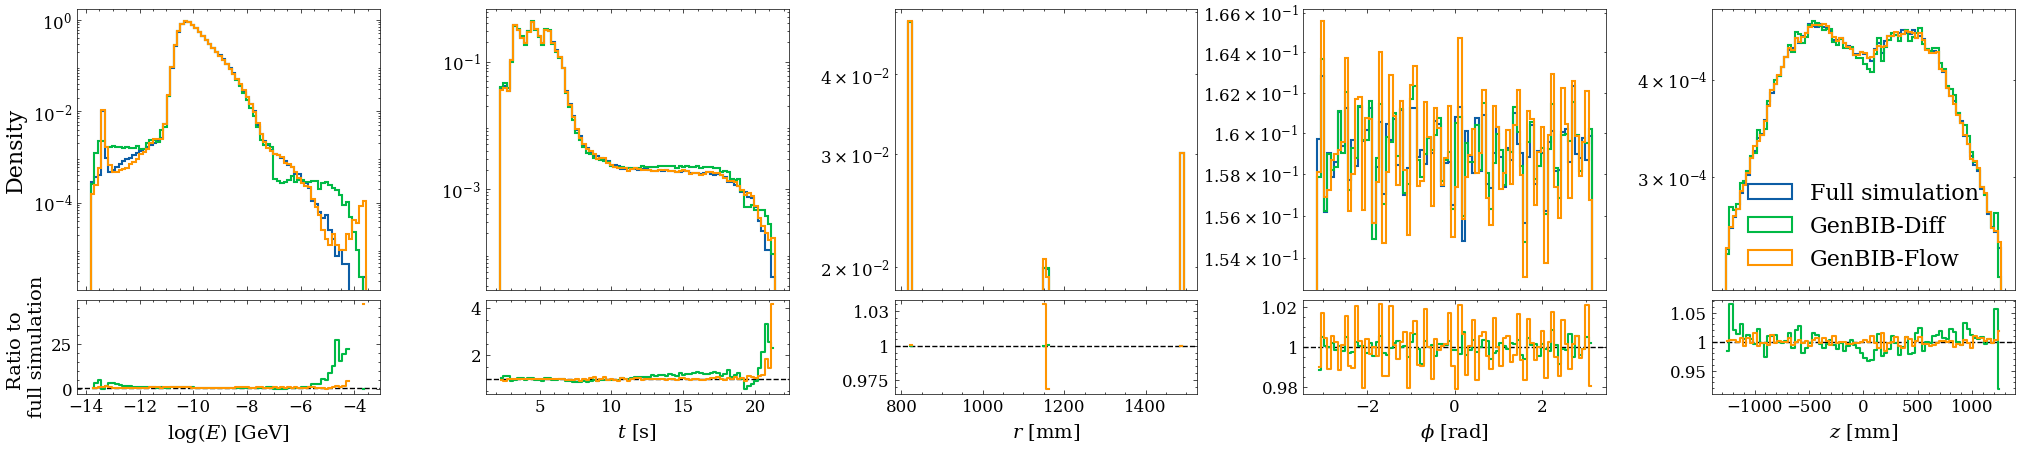

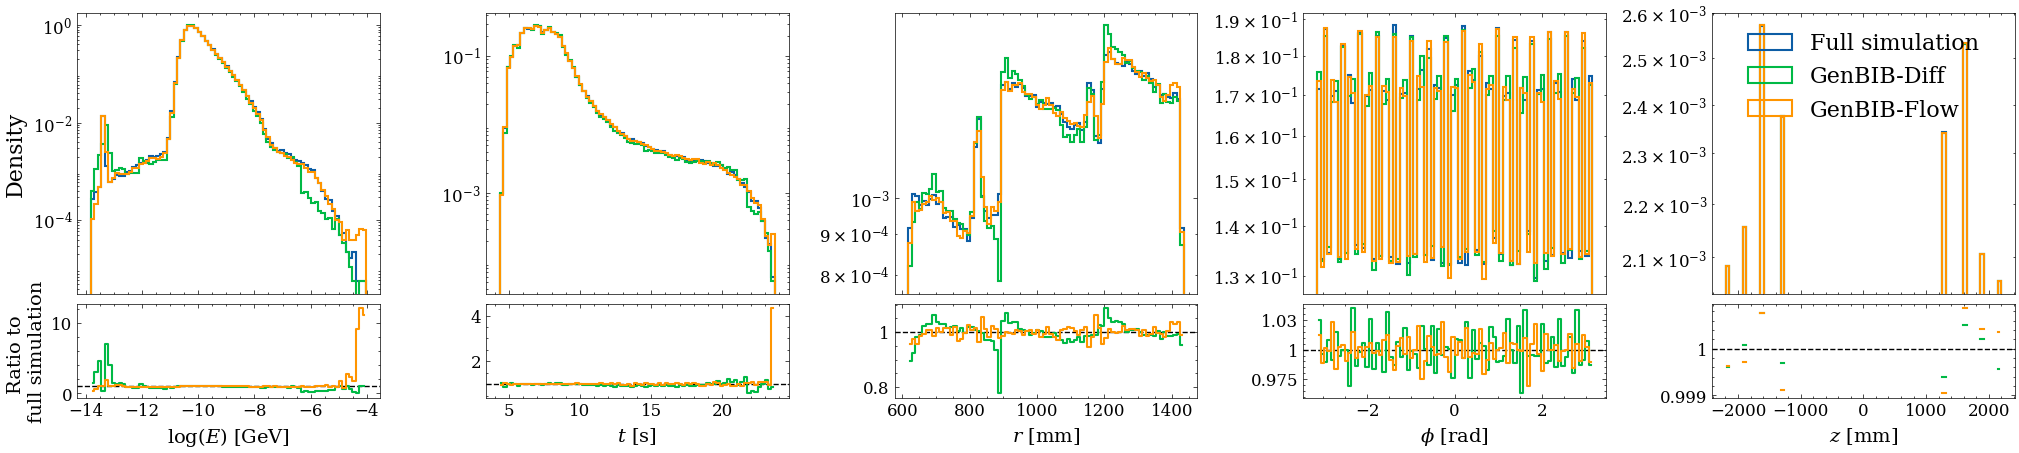

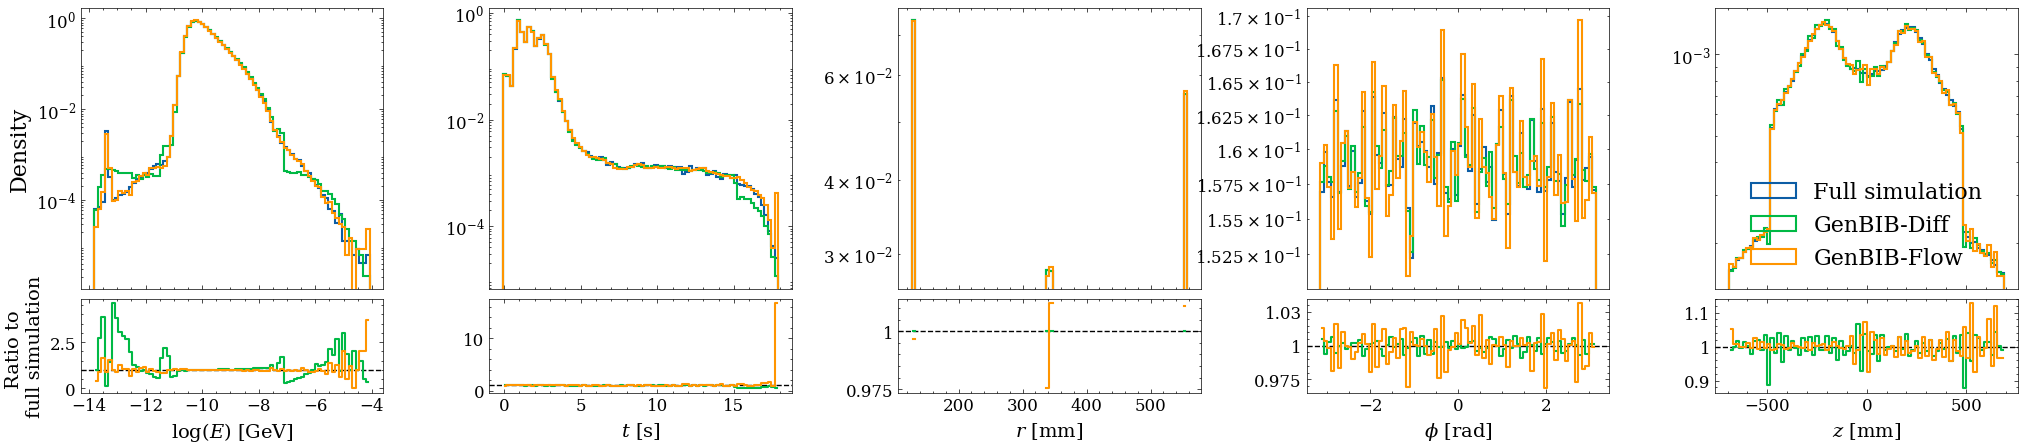

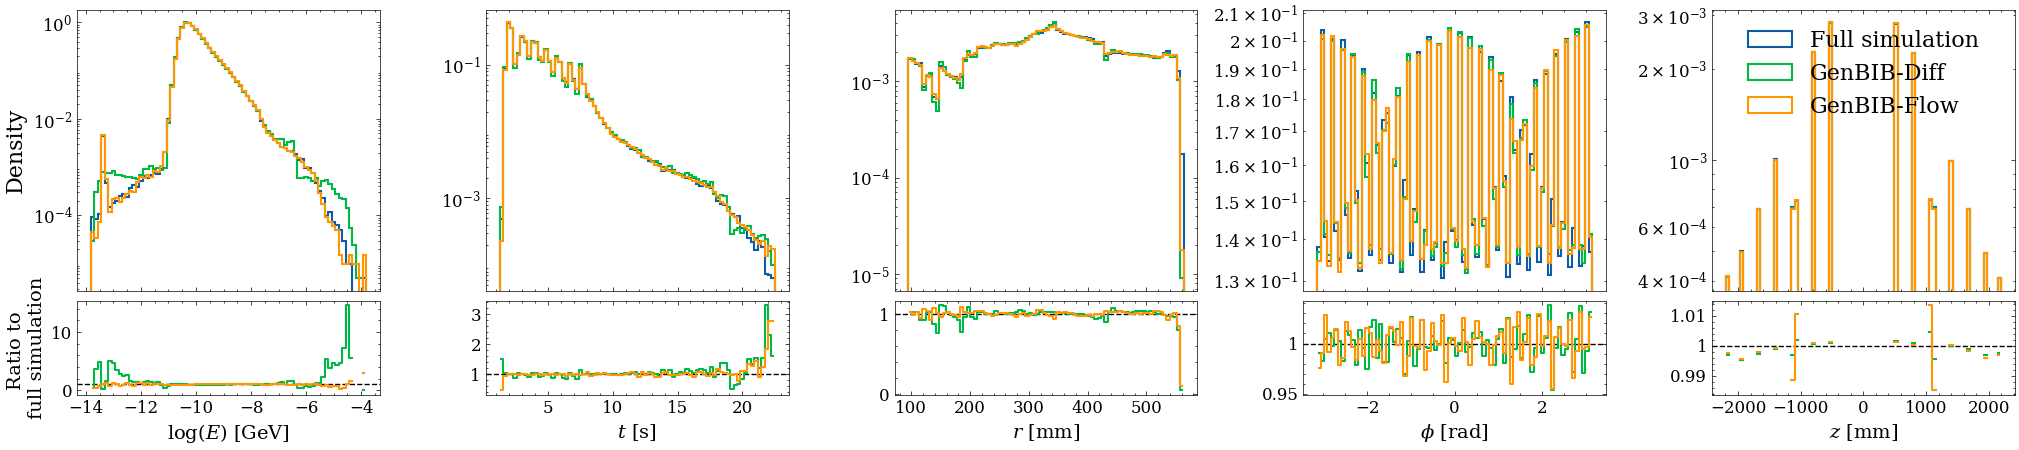

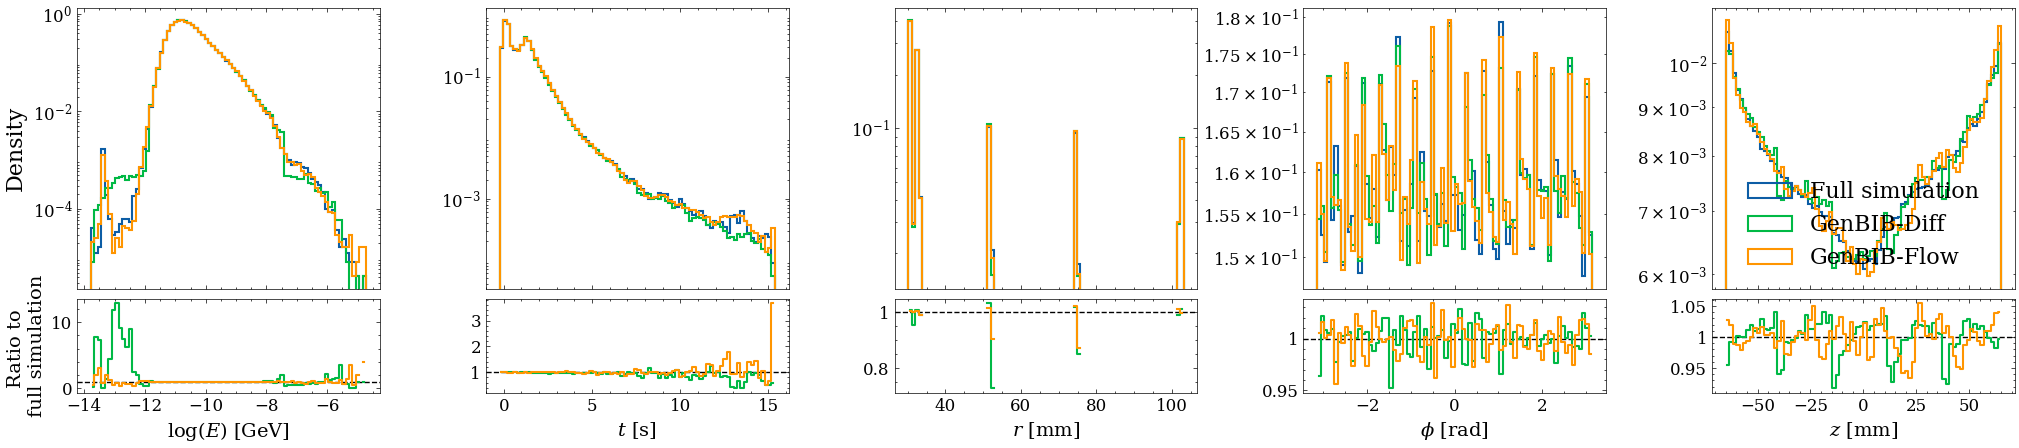

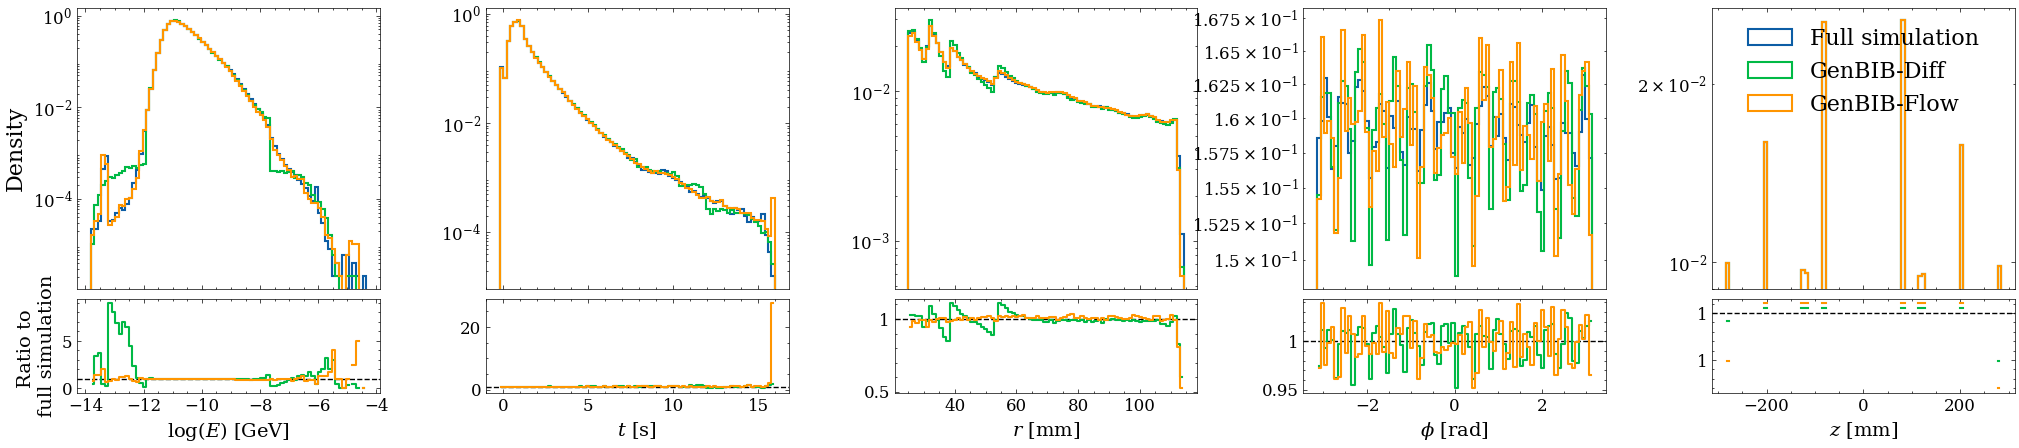

In [16]:
# ML BIB vs Sim BIB: all models overlaid, per collection

from matplotlib.ticker import LogLocator, FuncFormatter, LogFormatterSciNotation


n_bins = 80
eps = 1e-12
feature_labels = ["log($E$) [GeV]", "$t$ [s]", "$r$ [mm]", "$\\phi$ [rad]", "$z$ [mm]"]
fmt_1sf = FuncFormatter(lambda x, _: f"{x:.1e}")
fmt_3sf = FuncFormatter(lambda x, _: f"{x:.3g}")

for col_name in ALL_COLLECTIONS:

    fig, ax = plt.subplots(
        2, 5,
        figsize=(25, 5),
        sharex="col",
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
    )

    for i in range(5):
        ax[0, i].set_yscale("log")
        data_vals = all_data_dir[col_name][:, i]

        bins = np.histogram_bin_edges(data_vals, bins=n_bins)
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        data_hist, _ = np.histogram(data_vals, bins=bins, density=True)

        # Sim BIB (top panel)
        ax[0, i].hist(
            data_vals, bins=bins, density=True,
            histtype="step", linewidth=1.5, label="Full simulation",
        )

        ax[1, i].axhline(1.0, linestyle="--", linewidth=1, color="k")
        ax[1, i].set_xlabel(feature_labels[i], fontsize=14)
        if i == 0:
            ax[0, i].set_ylabel("Density", fontsize=16)
            ax[1, i].set_ylabel("Ratio to \nfull simulation", fontsize=14)

        # Each model overlaid
        for model_key, model_label in MODELS.items():
            flow_vals = all_samples_dir[model_key][col_name][:, i]
            flow_hist, _ = np.histogram(flow_vals, bins=bins, density=True)
            ratio = np.divide(
                flow_hist, data_hist,
                out=np.full_like(flow_hist, np.nan, dtype=float),
                where=data_hist > eps,
            )
            _, _, patches = ax[0, i].hist(
                flow_vals, bins=bins, density=True,
                histtype="step", linewidth=1.5, label=model_key,
            )
            model_color = patches[0].get_edgecolor()
            ax[1, i].step(bin_centers, ratio, where="mid", linewidth=1.5, label=model_key, color=model_color)

        # Apply formatting after all data is plotted so y-limits are final
        
        ax[0, i].yaxis.set_major_locator(LogLocator(base=10, numticks=3))
        ax[0, i].yaxis.set_major_formatter(LogFormatterSciNotation(base=10, labelOnlyBase=False))

        ax[0, i].tick_params(labelsize=12)

        ax[1, i].yaxis.set_major_formatter(fmt_3sf)
        ax[1, i].tick_params(labelsize=12)

    handles, labels = ax[0, 0].get_legend_handles_labels()
    ax[0, -1].legend(
        handles, labels,
        loc="lower center" if "Barrel" in col_name else "upper center",
        ncol=1,
        frameon=False,
        fontsize=16,
    )

    plt.subplots_adjust(wspace=0.35)
    plt.savefig(f"plots/diff_vs_sim_{col_name}.pdf", bbox_inches="tight", dpi=300)
    plt.show()


In [ ]:

# ML BIB vs Sim BIB: all models overlaid, per collection


n_bins = 80
eps = 1e-12
N = 10

for col_name in ALL_COLLECTIONS:

    fig, ax = plt.subplots(
        1, 3,
        figsize=(27, 7.5),
        sharex="col",
    )

    x_data = all_data_dir[col_name][::N, 2]*np.cos(all_data_dir[col_name][::N, 3])
    y_data = all_data_dir[col_name][::N, 2]*np.sin(all_data_dir[col_name][::N, 3])
    ax[0].scatter(x_data, y_data, s=0.01, rasterized=True)
    ax[0].set_title("Full simulation")
    ax[0].set_xlabel("$x$ [mm]")
    ax[0].set_ylabel("$y$ [mm]")
    ax[0].set_aspect('equal', adjustable='box')
    

    for i, (model_key, model_label) in enumerate(MODELS.items()):

        x_samples = all_samples_dir[model_key][col_name][::N, 2]*np.cos(all_samples_dir[model_key][col_name][::N, 3])
        y_samples = all_samples_dir[model_key][col_name][::N, 2]*np.sin(all_samples_dir[model_key][col_name][::N, 3])
        ax[i+1].scatter(x_samples, y_samples, s=0.01, rasterized=True)
        ax[i+1].set_title(model_key)
        ax[i+1].set_xlabel("$x$ [mm]")
        ax[i+1].set_ylabel("$y$ [mm]")
        ax[i+1].set_aspect('equal', adjustable='box')





    #fig.suptitle(col_name, fontsize=14, y=0.95)
    plt.subplots_adjust(wspace=0.05)
    plt.savefig(f"plots/xy_{col_name}.pdf", bbox_inches="tight", dpi=300)
    plt.show()


In [ ]:
# Sim BIB

feature_labels = ["log($E$) [GeV]", "$t$ [s]", "$r$ [mm]", "$\\phi$ [rad]", "$z$ [mm]"]

fig, ax = plt.subplots(
    3, 2,
    figsize=(10, 11),
    sharey=False
)

for i in range(5):
    row, col = divmod(i, 2)

    # Common binning across collections
    vals = np.concatenate([
        all_data_dir[col_name][:, i]
        for col_name in ALL_COLLECTIONS
    ])
    bins = np.histogram_bin_edges(vals, bins=50)

    for col_name in ALL_COLLECTIONS:
        ax[row, col].hist(
            all_data_dir[col_name][:, i],
            bins=bins,
            density=True,
            histtype="step",
            linewidth=1.5,
            label=col_name,
        )

    ax[row, col].set_xlabel(feature_labels[i], fontsize=14)
    ax[row, col].set_ylabel("Density", fontsize=14)
    ax[row, col].set_yscale("log")
    ax[row, col].tick_params(labelsize=12)

# Legend in the 6th (empty) panel at position [2, 1]
handles, labels = ax[0, 0].get_legend_handles_labels()
ax[2, 1].legend(
    handles,
    labels,
    loc="center",
    ncol=1,
    frameon=False,
    fontsize=14,
)
ax[2, 1].axis("off")

plt.tight_layout()
plt.savefig(f"plots/training_data_collections.pdf", bbox_inches="tight", dpi=300)
plt.show()
plt.close()


In [ ]:

# plt.figure()
# for col_name in ALL_COLLECTIONS:
#     plt.scatter(np.abs(all_data_dir[col_name][:1000000,4]), all_data_dir[col_name][:1000000,2], label = col_name, s = 0.00001)

# plt.ylabel("$r$ [mm]", fontsize = 14)
# plt.xlabel("$|z|$ [mm]", fontsize = 14)
# plt.gca().set_aspect("equal", adjustable="box")

# plt.legend(markerscale=1000, loc = (1,0), fontsize = 14)
# plt.show()


In [ ]:
plt.figure()
plt.hist(
    np.abs(all_data_dir["VertexEndcapCollection"][:, 4]),
    bins=np.linspace(75, 100, 1000),
    density=True,
    histtype="step",
    linewidth=1.5,
    label="OuterTrackerEndcapCollection",
)
plt.show()

# 7


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
samps_0 = np.load("/scratch/midway3/rmastand/muon_collider/ddpm_outputs/diff_OTBC_cond4/generated_samples.npy", allow_pickle=True)
samps_1 = np.load("/scratch/midway3/rmastand/muon_collider/ddpm_outputs/diff_OTBC_cond4/generated_samples_from_context_1.npy", allow_pickle=True)

In [ ]:
for i in range(9):
    plt.figure()
    print(samps_0[:,i])
    print(samps_1[:,i])
    plt.hist(samps_0[:,i], bins=200, density=True, histtype="step", label="samps_0")
    plt.hist(samps_1[:,i], bins=200, density=True, histtype="step", label="samps_1")
    plt.legend()
    plt.title(f"Feature {i}")
    plt.show()